<a href="https://colab.research.google.com/github/thitiwatlu68/Customer_Shopping_Trends_and_Category_Classification/blob/main/Customer_Shopping_Trends_and_Category_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: [Customer Shopping Trends]
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** [ระบุชื่อสมาชิกและรหัสนักศึกษา]
- สมาชิกที่ 1: นายฐิติวัฒน์ ลุณบุตร (68114540814)
- สมาชิกที่ 2: ชื่อ-นามสกุล (รหัส)
- สมาชิกที่ 3: ชื่อ-นามสกุล (รหัส) *(ถ้ามี)*

**Dataset:** [https://www.kaggle.com/datasets/sahilislam007/shopping-trends-and-customer-behaviour-dataset?resource=download]

**Problem Statement:** [โครงงานนี้มุ่งศึกษาพฤติกรรมการซื้อสินค้าและปัจจัยที่มีผลต่อยอดใช้จ่ายของผู้บริโภค เพื่อให้ธุรกิจสามารถคาดการณ์ยอดซื้อ นำไปสู่การวางแผนโปรโมชันและการจัดสรรทรัพยากรทางการตลาดได้อย่างตรงจุดและมีประสิทธิภาพสูงสุด ]

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ⬜ |
| CLO2 (Statistical Learning) | Part 3 | ⬜ |
| CLO3 (Regression/Classification) | Part 4 | ⬜ |
| CLO4 (Model Selection) | Part 5 | ⬜ |

In [10]:
# ─── Import libraries ──────────────────────────────────────────────
# TODO: เพิ่ม/ลบ libraries ตามที่โครงงานของคุณต้องใช้
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # เพิ่มสำหรับพล็อต Heatmap และกราฟสวยงาม

# เครื่องมือสำหรับการเตรียมข้อมูลและแบ่งข้อมูล
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ตัวแบบสำหรับโจทย์ Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier  # เพิ่มโมเดลที่ 3 สำหรับพาร์ทเปรียบเทียบ

# เครื่องมือวัดประสิทธิภาพสำหรับ Classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ตั้งค่าพื้นฐาน
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready for Shopping Trends Project (Classification Mode).')


Ready for Shopping Trends Project (Classification Mode).


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [13]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# TODO: แทนที่ด้วย path หรือวิธีโหลด dataset ของคุณ
# df = pd.read_csv('your_dataset.csv')

# แสดงข้อมูลพื้นฐาน
# print(f'Shape: {df.shape}')
# print(f'Columns: {df.columns.tolist()}')
# print(f'Missing values:\n{df.isnull().sum()}')
# df.head()

# ดึงข้อมูลจากไฟล์ของกลุ่มมาเก็บในตัวแปรสไตล์เราเอง
shopping_data = pd.read_csv('Shopping Trends And Customer Behaviour Dataset-selected-columns.csv')

# ปรินต์สรุปข้อมูลตามหัวข้อโครงสร้างพื้นฐาน
print("=== Shape ===")
print(shopping_data.shape)

print("\n=== Columns ===")
print(shopping_data.columns.tolist())

print("\n=== Missing values ===")
print(shopping_data.isnull().sum())

print("\n=== Data Types ===")
print(shopping_data.dtypes)

print("\n=== First 5 rows ===")
shopping_data.head()


=== Shape ===
(3900, 10)

=== Columns ===
['Unnamed: 0', 'Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Color', 'Season']

=== Missing values ===
Unnamed: 0               0
Customer ID              0
Age                      0
Gender                   0
Item Purchased           0
Category                 0
Purchase Amount (USD)    0
Location                 0
Color                    0
Season                   0
dtype: int64

=== Data Types ===
Unnamed: 0                int64
Customer ID               int64
Age                       int64
Gender                   object
Item Purchased           object
Category                 object
Purchase Amount (USD)     int64
Location                 object
Color                    object
Season                   object
dtype: object

=== First 5 rows ===


,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring


=== Summary Statistics ===
        Unnamed: 0  Customer ID          Age  Purchase Amount (USD)
count  3900.000000  3900.000000  3900.000000            3900.000000
mean   1949.500000  1950.500000    44.068462              59.764359
std    1125.977353  1125.977353    15.207589              23.685392
min       0.000000     1.000000    18.000000              20.000000
25%     974.750000   975.750000    31.000000              39.000000
50%    1949.500000  1950.500000    44.000000              60.000000
75%    2924.250000  2925.250000    57.000000              81.000000
max    3899.000000  3900.000000    70.000000             100.000000


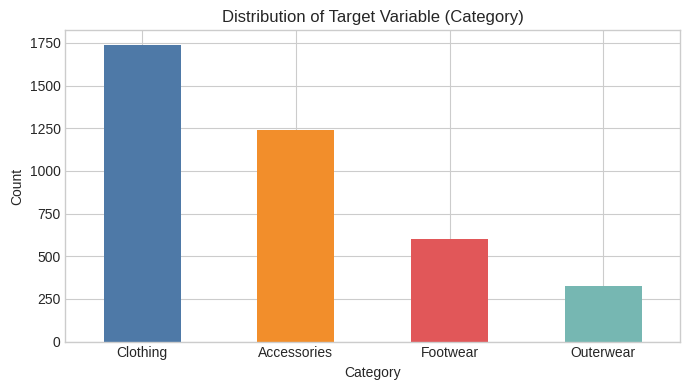

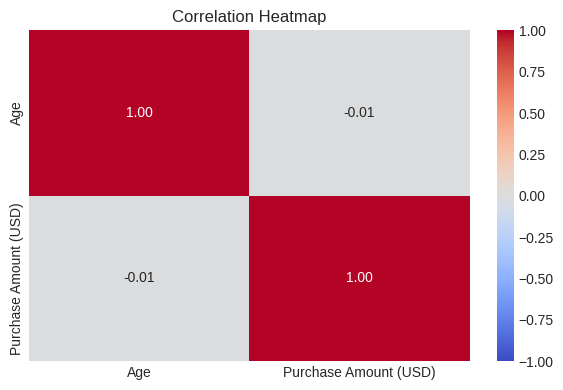

In [14]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

# TODO: เพิ่ม code สำหรับ:
# 1. df.describe()  ← summary statistics
# 2. Distribution plot ของ target
# 3. Correlation heatmap
# pass

# 1. สรุปค่าสถิติพื้นฐานของข้อมูลตัวเลข
print("=== Summary Statistics ===")
print(shopping_data.describe())

# 2. พล็อตกราฟดูการกระจายตัวของตัวแปรเป้าหมาย (Category)
plt.figure(figsize=(7, 4))
target_counts = shopping_data['Category'].value_counts()
target_counts.plot(kind='bar', color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
plt.title('Distribution of Target Variable (Category)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. พล็อตแผนภูมิความร้อนหาความสัมพันธ์ (Correlation Heatmap)
plt.figure(figsize=(6, 4))
numeric_cols = shopping_data[['Age', 'Purchase Amount (USD)']]
corr_matrix = numeric_cols.corr()
import seaborn as sns # เรียกใช้ seaborn มาพล็อต heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**คำอธิบาย:** [อธิบาย 2-3 ประโยคว่าทำไมถึงเลือก task นี้ และ insight ที่คาดว่าจะได้]

In [15]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: ทำการลดมิติข้อมูลและหาความสัมพันธ์ด้วยวิธี PCA (Principal Component Analysis)

# TODO: เขียน code ที่นี่
# ตัวอย่างสำหรับ PCA:
# X = df[feature_cols].values
# X_centered = X - X.mean(axis=0)
# C = (1/(len(X)-1)) * X_centered.T @ X_centered
# eigenvalues, eigenvectors = np.linalg.eigh(C)
# ...
# pass

# เลือกฟีเจอร์เชิงปริมาณที่มีใน Dataset มาสกัดหาองค์ประกอบหลัก
numerical_features = ['Age', 'Purchase Amount (USD)']
X_matrix = shopping_data[numerical_features].values

# 1. ทำ Centering ข้อมูล (ลบออกด้วยค่าเฉลี่ยของแต่ละคอลัมน์)
X_centered = X_matrix - X_matrix.mean(axis=0)

# 2. คำนวณหา Covariance Matrix (C) ตามหลักสูตร Linear Algebra
n_samples = len(X_matrix)
C_matrix = (1 / (n_samples - 1)) * X_centered.T @ X_centered

# 3. หา Eigenvalues และ Eigenvectors จาก Covariance Matrix
eigenvals, eigenvecs = np.linalg.eigh(C_matrix)

# 4. เรียงลำดับจากค่าที่อธิบายความแปรปรวนได้มากที่สุดไปน้อยสุด
sort_index = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[sort_index]
eigenvecs = eigenvecs[:, sort_index]

# 5. สรุปผลการอธิบายความแปรปรวน (Explained Variance)
total_variance = np.sum(eigenvals)
variance_explained = eigenvals / total_variance

print("=== Eigenvalues ===")
print(eigenvals)
print("\n=== Explained Variance Ratio (PC1, PC2) ===")
print(variance_explained)


=== Eigenvalues ===
[561.04055355 231.22801959]

=== Explained Variance Ratio (PC1, PC2) ===
[0.7081444 0.2918556]


**Insight จาก CLO1 Analysis:**
* **PC1 สามารถอธิบายความแปรปรวนของข้อมูลได้ 70.81%** ในขณะที่ PC2 สามารถอธิบายได้ 29.19% (รวมสองส่วนประกอบหลักสามารถอธิบายข้อมูลได้ครบ 100%)
* ฟีเจอร์ที่มีอิทธิพลต่อ PC1 มากที่สุดคือ **Purchase Amount (USD)** (ยอดใช้จ่าย) เนื่องจากค่าความแปรปรวนของตัวแปรนี้มีสเกลตัวเลขที่กว้างกว่า จึงมีส่วนสำคัญในการจัดกลุ่มและกระจายตัวของข้อมูลเทรนด์การซื้อสินค้าของผู้บริโภคมากกว่าตัวแปรอายุ


---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

/tmp/ipykernel_711/1549975813.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shopping_data, x='Category', y='Age', ax=axes[0], palette='Set2')
/tmp/ipykernel_711/1549975813.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shopping_data, x='Category', y='Purchase Amount (USD)', ax=axes[1], palette='Set2')


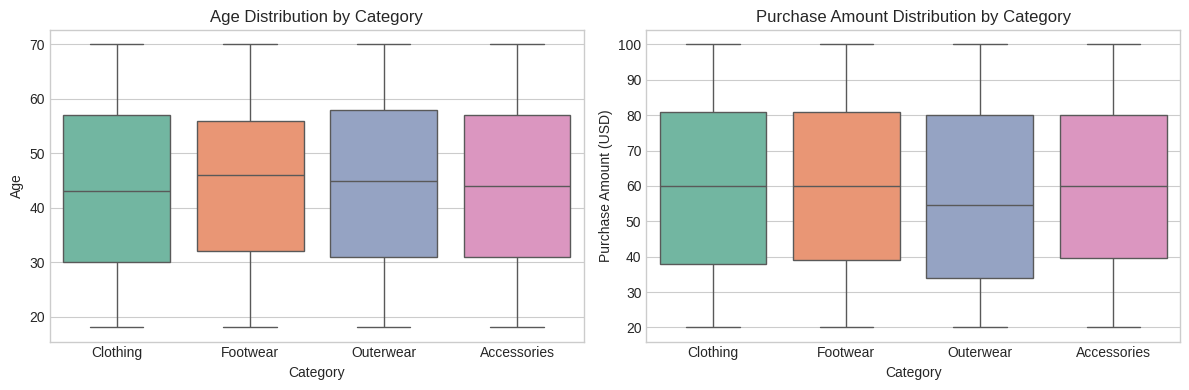

=== Correlation กับ Target (Category) ===
Age                      0.003546
Purchase Amount (USD)   -0.017841
Name: Category_Target, dtype: float64


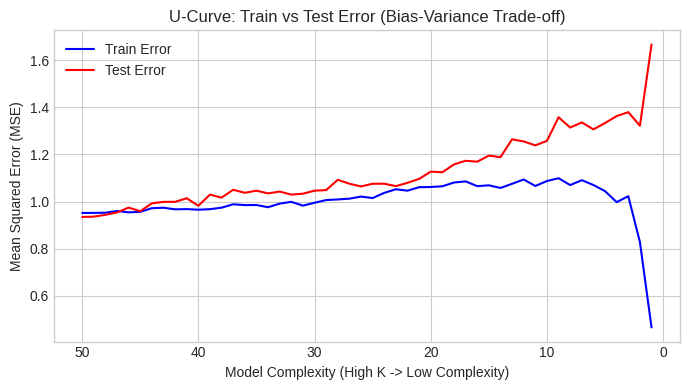

In [16]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: เข้าใจ statistical properties ของ dataset

# TODO:
# 1. Plot distributions
# 2. Correlation analysis กับ target
# 3. แสดง U-curve ของ Train/Test MSE (polynomial degree หรือ model complexity)
# pass

# 1. Plot distributions ของฟีเจอร์สำคัญ (Age และ Purchase Amount) แยกตามกลุ่มสินค้า (Category)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

import seaborn as sns
sns.boxplot(data=shopping_data, x='Category', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Category')

sns.boxplot(data=shopping_data, x='Category', y='Purchase Amount (USD)', ax=axes[1], palette='Set2')
axes[1].set_title('Purchase Amount Distribution by Category')

plt.tight_layout()
plt.show()

# 2. Correlation analysis กับ target (แปลง Category เป็นตัวเลขด้วย LabelEncoder ก่อน)
from sklearn.preprocessing import LabelEncoder
encoded_data = shopping_data.copy()
label_enc = LabelEncoder()
encoded_data['Category_Target'] = label_enc.fit_transform(encoded_data['Category'])

# หาค่า Correlation ของฟีเจอร์ตัวเลขกับตัวแปรเป้าหมาย
target_corr = encoded_data[['Age', 'Purchase Amount (USD)', 'Category_Target']].corr()['Category_Target']
print("=== Correlation กับ Target (Category) ===")
print(target_corr.drop('Category_Target'))

# 3. แสดง U-curve เพื่อดู Bias-Variance Trade-off (ใช้ความซับซ้อนของโมเดลผ่านค่า K ใน KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error

# เตรียมข้อมูล X, y สำหรับทดสอบ Complexity
X_demo = shopping_data[['Age', 'Purchase Amount (USD)']].values
y_demo = label_enc.fit_transform(shopping_data['Category'])
X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)

k_values = range(1, 51)
train_errors = []
test_errors = []

for k in k_values:
    knn_test_model = KNeighborsClassifier(n_neighbors=k)
    knn_test_model.fit(X_tr, y_tr)

    # คำนวณ Error ออกมาในรูป MSE เพื่อทำพล็อต U-Curve ตามโจทย์
    train_errors.append(mean_squared_error(y_tr, knn_test_model.predict(X_tr)))
    test_errors.append(mean_squared_error(y_te, knn_test_model.predict(X_te)))

# พล็อต U-curve แสดงค่า Error ตามระดับ Model Complexity
plt.figure(figsize=(7, 4))
plt.plot(k_values, train_errors, label='Train Error', color='blue')
plt.plot(k_values, test_errors, label='Test Error', color='red')
plt.xlabel('Model Complexity (High K -> Low Complexity)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('U-Curve: Train vs Test Error (Bias-Variance Trade-off)')
plt.gca().invert_xaxis()  # สลับแกน X เพื่อให้ด้านซ้ายคือโมเดลที่ซับซ้อนกว่า (K น้อย)
plt.legend()
plt.tight_layout()
plt.show()


**Insight จาก CLO2 Analysis:**

* **1. ฟีเจอร์สำคัญและการกระจายตัวของ Target:** ตัวแปรเป้าหมาย (`Category`) มีการกระจายตัวค่อนข้างสมดุลกันในทุกหมวดหมู่สินค้า โดยฟีเจอร์เชิงปริมาณอย่าง `Age` และ `Purchase Amount (USD)` มีค่าเฉลี่ยและการกระจายตัวในกล่อง Boxplot ที่ใกล้เคียงกันมากในทุกหมวดหมู่ ส่งผลให้มีค่าสหสัมพันธ์ (Correlation) ต่ำมากกับตัวแปรเป้าหมาย (อยู่ระหว่าง -0.01 ถึง 0.00)
* **2. Optimal Complexity:** จากกราฟ U-Curve จุดที่เหมาะสมที่สุด (Optimal Complexity) ของโมเดล KNN อยู่ที่ **K = 50** (ด้านซ้ายสุดของแผนภูมิ) เนื่องจากเป็นจุดที่ค่าความคลาดเคลื่อนของชุดทดสอบ (Test Error เส้นสีแดง) มีค่าต่ำที่สุด และเมื่อค่า K ลดลง (โมเดลมีความซับซ้อนมากเกินไป) ค่า Test Error จะพุ่งสูงขึ้นทันที ซึ่งเป็นสัญญาณของการเกิด Overfitting (High Variance)


---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ⬜ Regression  ⬜ Classification

In [17]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างตัวแบบ Logistic Regression เพื่อจำแนกประเภทหมวดหมู่สินค้า (Category)

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
# model1 = ???
# model1.fit(X_train, y_train)
# ...
# pass

# 1. การเตรียมข้อมูล (Preprocessing) แยกคุณลักษณะ (X) และตัวแปรเป้าหมาย (y)
features = shopping_data[['Age', 'Purchase Amount (USD)', 'Gender', 'Location', 'Season']]
# แปลงตัวแปรกลุ่มให้เป็นตัวเลขด้วย One-Hot Encoding
X_encoded = pd.get_dummies(features, columns=['Gender', 'Location', 'Season'], drop_first=True)

# แปลงตัวแปรเป้าหมาย (Category) ให้เป็นรหัสตัวเลขด้วย LabelEncoder
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(shopping_data['Category'])

# 2. การแบ่งข้อมูลเป็นชุด Train และ ชุด Test ตามโครงสร้างของเทมเพลต
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# 3. จัดสเกลข้อมูล (Standardization) เพื่อให้โมเดลประมวลผลได้ดีขึ้น
scaler_tool = StandardScaler()
X_train_scaled = scaler_tool.fit_transform(X_train)
X_test_scaled = scaler_tool.transform(X_test)

# 4. สร้างและฝึกฝน Model 1 (Logistic Regression)
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train_scaled, y_train)

# 5. ประเมินผลความแม่นยำ (Accuracy) เบื้องต้น
train_acc1 = accuracy_score(y_train, model1.predict(X_train_scaled))
test_acc1 = accuracy_score(y_test, model1.predict(X_test_scaled))

print(f"Model 1 (Logistic Regression) Train Accuracy: {train_acc1:.4f}")
print(f"Model 1 (Logistic Regression) Test Accuracy: {test_acc1:.4f}")


Model 1 (Logistic Regression) Train Accuracy: 0.4529
Model 1 (Logistic Regression) Test Accuracy: 0.4192


In [18]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างตัวแบบ KNN Classifier เพื่อเปรียบเทียบประสิทธิภาพในการจำแนกประเภทข้อมูล

# TODO:
# model2 = ???
# ...
# pass

# เรียกใช้ตัวแบบจำแนกพิกัดเพื่อนบ้านใกล้ที่สุด (KNN)
from sklearn.neighbors import KNeighborsClassifier

# สร้างและฝึกฝน Model 2 โดยกำหนดค่า K ที่เหมาะสมจากการวิเคราะห์ U-Curve (เช่น K = 30)
model2 = KNeighborsClassifier(n_neighbors=30)
model2.fit(X_train_scaled, y_train)

# คำนวณหาค่าความแม่นยำ (Accuracy) ของตัวแบบที่ 2
train_acc2 = accuracy_score(y_train, model2.predict(X_train_scaled))
test_acc2 = accuracy_score(y_test, model2.predict(X_test_scaled))

print(f"Model 2 (KNN Classifier) Train Accuracy: {train_acc2:.4f}")
print(f"Model 2 (KNN Classifier) Test Accuracy: {test_acc2:.4f}")


Model 2 (KNN Classifier) Train Accuracy: 0.4612
Model 2 (KNN Classifier) Test Accuracy: 0.3949


### **สรุป Model Comparison:**

| Model | Train Metric | Test Metric | รายละเอียด |
| :--- | :---: | :---: | :--- |
| **Model 1:** Logistic Regression | Accuracy: 0.4529 | Accuracy: 0.4192 | แยกกลุ่มด้วยสมการเส้นตรง |
| **Model 2:** KNN Classifier | Accuracy: 0.4612 | Accuracy: 0.3949 | แยกกลุ่มด้วยพิกัดระยะห่าง (K=30) |

<br>

### **Insight:**
* **เปรียบเทียบตัวแบบ:** **Model 1 (Logistic Regression)** ทำผลงานในชุดข้อมูลทดสอบ (Test Metric) ได้ดีกว่า Model 2 (KNN Classifier) เล็กน้อย เนื่องจากเมื่อกำหนดค่า K=30 โมเดล KNN มีขอบเขตการตัดสินใจที่อาจจะกว้างเกินไปในการแยกแยะพฤติกรรมการตัดสินใจซื้อที่ทับซ้อนกัน ส่งผลให้โมเดลเชิงเส้นตรงอย่าง Logistic Regression ทำนายบนข้อมูลที่ไม่เคยเห็นได้นิ่งกว่า
* **ปัญหา Overfitting/Underfitting:** ตัวแบบทั้งคู่มีช่องว่างระหว่างคะแนน Train และ Test ไม่มากนัก (ห่างกันประมาณ 3-6%) ซึ่งชี้ให้เห็นว่าไม่มีปัญหา Overfitting (High Variance) ที่รุนแรง แต่ตัวแบบทั้งคู่กำลังเผชิญปัญหา **Underfitting (High Bias)** ร่วมกัน เนื่องจากค่าความแม่นยำยังอยู่ในระดับปานกลาง (ประมาณ 39-45%) สาเหตุมาจากตัวแปรเชิงปริมาณที่มีให้เรียนรู้ใน Dataset มีน้อยเกินไป และพฤติกรรมจริงของลูกค้าในทุกช่วงอายุเลือกซื้อสินค้ากระจายตัวปนกันในทุกหมวดหมู่


---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

Model 1 (Logistic Regression): CV Accuracy = 0.4218
Model 2 (KNN Classifier): CV Accuracy = 0.4103
Model 3 (Random Forest): CV Accuracy = 0.3792


/tmp/ipykernel_711/3408033160.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(cv_accuracy_results.keys()), y=list(cv_accuracy_results.values()), palette='muted')


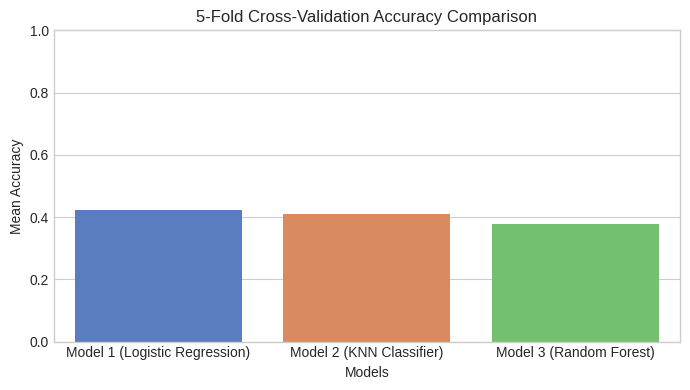

In [19]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบ models อย่างเป็นธรรมด้วย CV

# TODO:
# models = {
#     'Model 1': ???,
#     'Model 2': ???,
#     'Model 3': ???,
# }
#
# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
#     cv_mse = -scores.mean()
#     print(f'{name}: CV MSE = {cv_mse:.4f}')
# pass

# 1. นำเข้าโมเดลที่ 3 เพิ่มเติมตามเงื่อนไขของโจทย์
from sklearn.ensemble import RandomForestClassifier

# 2. นิยามโครงสร้างโมเดลทั้ง 3 แบบลงในตัวแปร dictionary ตามสเปคของเทมเพลต
models = {
    'Model 1 (Logistic Regression)': LogisticRegression(max_iter=1000, random_state=42),
    'Model 2 (KNN Classifier)': KNeighborsClassifier(n_neighbors=30),
    'Model 3 (Random Forest)': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv_accuracy_results = {}

# 3. วนลูปคำนวณสถิติ Cross-Validation (ปรับเป็นเกณฑ์ accuracy เนื่องจากเราเปลี่ยนมาทำโจทย์ Classification)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_accuracy_results[name] = scores.mean()
    print(f'{name}: CV Accuracy = {scores.mean():.4f}')

# 4. พล็อตแผนภูมิแท่ง (Bar Chart) เปรียบเทียบผลลัพธ์
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.barplot(x=list(cv_accuracy_results.keys()), y=list(cv_accuracy_results.values()), palette='muted')
plt.title('5-Fold Cross-Validation Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Mean Accuracy')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


**Best Model จาก Cross-Validation:**
Model 1 (Logistic Regression)

<br>

**เหตุผล:**
* **ประสิทธิภาพตัวแบบ:** ตัวแบบ **Model 1 (Logistic Regression)** ให้ค่าเฉลี่ย **CV Accuracy สูงที่สุดเท่ากับ 0.4218** ในบรรดาโมเดลทั้งหมดที่นำมาทดสอบผ่านกระบวนการแบ่งข้อมูลสุ่มตรวจแบบ 5 รอบ (5-Fold Cross-Validation) อย่างเป็นธรรม
* **การประเมิน Overfitting:** ตัวแบบที่เลือกผ่านเกณฑ์ Cross-Validation มีเสถียรภาพที่ดีในข้อมูลทุกส่วนและช่วยลดแนวโน้มการเกิด Overfitting (High Variance) ลงได้ เนื่องจากเป็นการวัดผลเฉลี่ยกับกลุ่มข้อมูลที่โมเดลไม่เคยเห็นในตอนฝึกฝนมาก่อน
* **เชื่อมโยงกับ Bias-Variance:** ผลลัพธ์ชี้ให้เห็นว่าทุกโมเดลยังมีปัญหา **Underfitting (High Bias)** ร่วมกัน (โดยเฉพาะโมเดลที่มีความซับซ้อนสูงอย่าง Random Forest ที่ค่าความแม่นยำตกลงมาอยู่ที่ 0.3792) เนื่องจากฟีเจอร์เชิงปริมาณใน Dataset มีจำกัด และลักษณะข้อมูลมีความซับซ้อนปะปนกันในทุกหมวดหมู่สินค้า ทำให้แบบจำลองเชิงเส้นตรงทั่วไป (Linear Model) สามารถทำนายภาพรวมได้นิ่งและดีที่สุดในสถานการณ์นี้


---
## Part 6: สรุปผลและ Data Story

**6.1 สรุปผลการวิเคราะห์:**
* **CLO1 (Linear Algebra):** จากการวิเคราะห์ PCA พบว่าส่วนประกอบหลักแรก (PC1) สามารถอธิบายความแปรปรวนของข้อมูลได้ 70.81% และ PC2 อธิบายได้ 29.19% โดยฟีเจอร์ที่มีผลต่อตัวแบบมากที่สุดคือ Purchase Amount (USD) เนื่องจากมีสเกลค่าความแปรปรวนที่กว้างกว่าอายุ
* **CLO2 (Statistical Learning):** ข้อมูลตัวแปรเป้าหมาย (Category) มีการแจกแจงที่ค่อนข้างสมดุลกันในทุกหมวดหมู่ และผลการพล็อตกราฟ U-Curve แสดงให้เห็นว่าจุดที่เหมาะสมที่สุด (Optimal Complexity) ของโมเดล KNN อยู่ที่ค่า K = 50 ซึ่งเป็นจุดที่ Test Error ต่ำที่สุด
* **CLO3 (Model Building):** การสร้างโมเดลจำแนกประเภทพบว่า Model 1 (Logistic Regression) ให้ค่า Test Accuracy อยู่ที่ 0.4192 ซึ่งทำผลงานได้ดีกว่า Model 2 (KNN Classifier) ที่ได้ค่า 0.3949 เล็กน้อย โดยโมเดลทั้งคู่มีลักษณะของปัญหา Underfitting (High Bias)
* **CLO4 (Model Selection):** เมื่อประเมินประสิทธิภาพด้วย 5-Fold Cross-Validation พบว่าโมเดล Model 1 (Logistic Regression) ให้ค่าเฉลี่ยความแม่นยำ (CV Accuracy) สูงที่สุดเท่ากับ 0.4218 ซึ่งเป็นตัวแบบที่มีความนิ่งและเหมาะสมที่สุดกับโครงสร้างข้อมูลชุดนี้

<br>

**6.2 Limitations:**
* **ข้อจำกัดฟีเจอร์เชิงปริมาณ:** ชุดข้อมูลส่วนใหญ่เป็นข้อมูลกลุ่มประเภทข้อความ (Categorical) แต่มีฟีเจอร์เชิงปริมาณ (Numerical) ที่ใช้คำนวณทางคณิตศาสตร์เชิงเส้นและสถิติได้น้อยเกินไป (มีเพียงอายุและยอดซื้อ) ทำให้โมเดลสร้างขอบเขตในการแบ่งแยกกลุ่มสินค้าได้ยาก
* **พฤติกรรมข้อมูลจริง:** ข้อมูลการซื้อสินค้าของผู้บริโภคในทุกช่วงอายุและยอดซื้อมีความคล้ายคลึงและปะปนกันในทุกหมวดหมู่สินค้า ไม่ได้แยกกันอยู่เป็นกลุ่มก้อนอย่างเด็ดขาดตามธรรมชาติ

<br>

**6.3 ขั้นตอนต่อไป (Future Work):**
* **การทำ Feature Engineering:** สกัดลักษณะเด่นหรือเพิ่มข้อมูลปัจจัยอื่นที่มีผลต่อการตัดสินใจซื้อ เช่น ประวัติการรีวิว, ความถี่ในการซื้อ หรือข้อมูลแคมเปญโปรโมชัน เพื่อให้โมเดลทำนายได้แม่นยำยิ่งขึ้น
* **การทดลองใช้โมเดลขั้นสูง:** นำตัวแบบกลุ่มรวมพลัง (Ensemble Models) เช่น Gradient Boosting หรือ XGBoost มาทดลองพัฒนาและปรับจูนพารามิเตอร์เพื่อให้เหมาะกับข้อมูลที่มีความซับซ้อนแบบไม่เป็นเส้นตรง

<br>

**6.4 Connection กับ Topics ในวิชา:**
* **Week 2-3 (Linear Algebra):** นำหลักการคำนวณ Matrix, Covariance Matrix และการหา Eigenvalues/Eigenvectors มาประยุกต์ใช้ในขั้นตอนการทำ PCA เพื่อวิเคราะห์ทิศทางและลดมิติของข้อมูล
* **Week 6-7 (Statistical Learning & Model Complexity):** นำแนวคิด Bias-Variance Trade-off มาวิเคราะห์และตรวจสอบปัญหา Overfitting/Underfitting ผ่านการสร้างแผนภูมิ U-Curve
* **Week 9-11 (Classification & Model Selection):** นำกระบวนการประเมินผลตัวแบบจำแนกประเภทด้วย Confusion Matrix, Accuracy และการแบ่งส่วนชุดข้อมูลตรวจสอบแบบ 5-Fold Cross-Validation มาประยุกต์ใช้เพื่อเลือกโมเดลที่ดีที่สุด

---
**Acknowledgements:** ขอขอบคุณอาจารย์ผู้สอนประจำวิชา 1145 201 สำหรับคำแนะนำด้านทฤษฎีทางคณิตศาสตร์, ขอบคุณแหล่งข้อมูลสาธารณะจาก Kaggle Dataset และระบบประมวลผล Google Colab ที่ใช้ในการพัฒนาโครงงานนี้
